# Clawback - ML Training Pipeline
## Smart Consumer Complaint System

This notebook trains the machine learning models that power Clawback. We use the CFPB Consumer Complaint Database to:
1. **Classify** complaint types from raw text (NLP classification)
2. **Predict** likelihood of getting monetary relief (binary classification)
3. **Extract** patterns from successful complaints to guide letter generation

**Data Source:** CFPB Consumer Complaint Database (4M+ complaints, public)

**Run this notebook on Google Colab. Free. No GPU needed.**

## Cell 1: Install dependencies

In [1]:
!pip install pandas scikit-learn nltk joblib matplotlib seaborn wordcloud --quiet
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
print('Dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 18.9 MB/s eta 0:00:00
Dependencies installed.


## Cell 2: Download the CFPB dataset

The full dataset is ~2GB. We'll download a manageable sample (last 2 years of consumer narrative complaints) directly from the CFPB API.

In [2]:
import requests
import pandas as pd
from io import StringIO

# CFPB direct CSV download URL with filters: only complaints with narratives
url = 'https://files.consumerfinance.gov/ccdb/complaints.csv.zip'

print('Downloading CFPB dataset (~250MB compressed)... this takes 2-3 mins')
!wget -q --show-progress {url} -O /content/complaints.csv.zip
!unzip -q -o /content/complaints.csv.zip -d /content/
print('Dataset downloaded and extracted.')

/content/complaints 100%[===================>]   1.68G  37.8MB/s    in 47s     
Dataset downloaded and extracted.


## Cell 3: Load and explore the data

In [3]:
import pandas as pd

df = pd.read_csv('/content/complaints.csv', low_memory=False)
print(f'Total complaints loaded: {len(df):,}')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nFirst 3 rows:')
df.head(3)

Total complaints loaded: 14,533,627

Columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']

First 3 rows:


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2020-07-06,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,346XX,NaN,Other,Web,2020-07-06,Closed with explanation,Yes,NaN,3730948
1,2019-12-26,Credit card or prepaid card,General-purpose credit card or charge card,"Advertising and marketing, including promotion...",Confusing or misleading advertising about the ...,NaN,NaN,CAPITAL ONE FINANCIAL CORPORATION,CA,94025,NaN,Consent not provided,Web,2019-12-26,Closed with explanation,Yes,NaN,3477549
2,2020-05-08,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,These are not my accounts.,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,NV,89030,NaN,Consent provided,Web,2020-05-08,Closed with explanation,Yes,NaN,3642453


In [4]:
# Filter to complaints that have narratives (our text input for ML)
df = df[df['Consumer complaint narrative'].notna()].copy()
print(f'Complaints with narratives: {len(df):,}')

# Filter to recent complaints (last 3 years) to keep training time reasonable
df['Date received'] = pd.to_datetime(df['Date received'], errors='coerce')
df = df[df['Date received'] >= '2022-01-01'].copy()
print(f'After date filter (2022+): {len(df):,}')

# Sample to 100k rows for fast training (you can scale up later)
if len(df) > 100000:
    df = df.sample(n=100000, random_state=42).reset_index(drop=True)
print(f'Final training size: {len(df):,}')

Complaints with narratives: 3,761,119
After date filter (2022+): 2,892,442
Final training size: 100,000


## Cell 4: Exploratory Data Analysis (EDA)

Required for your data science course report. We'll generate:
- Distribution of complaints by category
- Resolution outcome distribution
- Top companies by complaint volume
- Word cloud of successful vs unsuccessful complaints

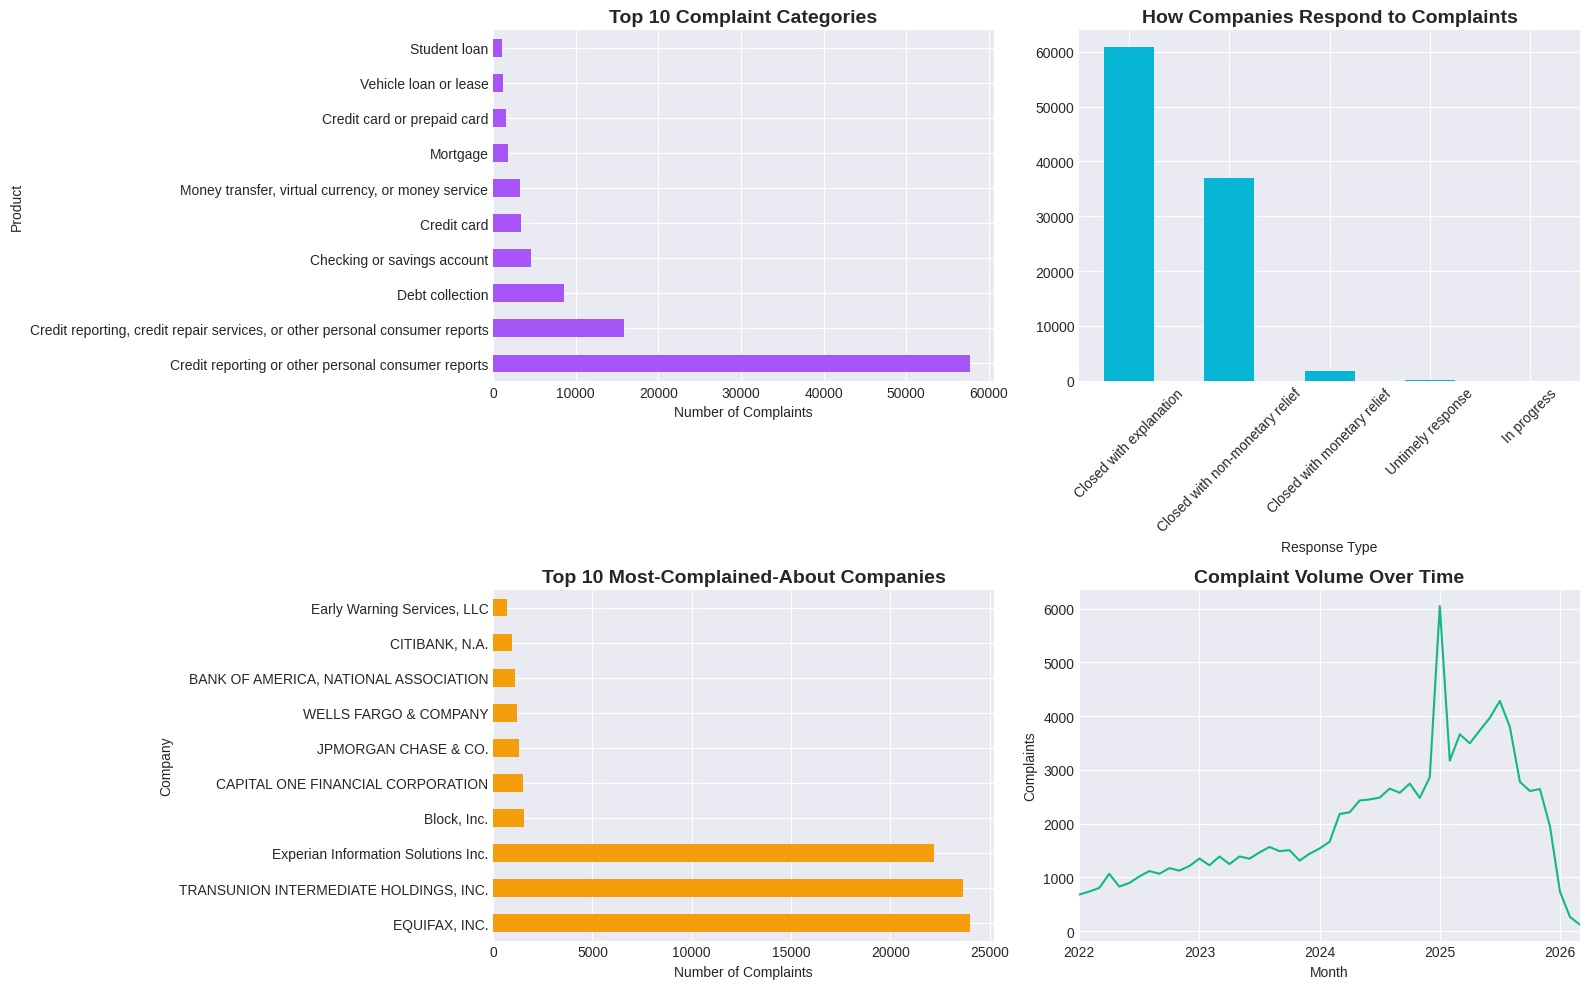

EDA visualizations saved to eda_overview.png


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Top 10 product categories
df['Product'].value_counts().head(10).plot(kind='barh', ax=axes[0,0], color='#a855f7')
axes[0,0].set_title('Top 10 Complaint Categories', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Number of Complaints')

# Plot 2: Company response distribution
df['Company response to consumer'].value_counts().head(7).plot(kind='bar', ax=axes[0,1], color='#06b6d4')
axes[0,1].set_title('How Companies Respond to Complaints', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Response Type')
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3: Top 10 companies by complaint volume
df['Company'].value_counts().head(10).plot(kind='barh', ax=axes[1,0], color='#f59e0b')
axes[1,0].set_title('Top 10 Most-Complained-About Companies', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Number of Complaints')

# Plot 4: Complaint volume over time
df.groupby(df['Date received'].dt.to_period('M')).size().plot(ax=axes[1,1], color='#10b981')
axes[1,1].set_title('Complaint Volume Over Time', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Complaints')

plt.tight_layout()
plt.savefig('/content/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA visualizations saved to eda_overview.png')

## Cell 5: Define the prediction target

We classify outcomes into three buckets:
- **Monetary Relief** (got money back) — the WIN outcome
- **Non-Monetary Relief** (account fix, correction)
- **Closed Without Relief** (got nothing)

In [6]:
def map_outcome(response):
    if pd.isna(response):
        return None
    response = str(response).lower()
    if 'monetary relief' in response and 'non-monetary' not in response:
        return 'monetary_relief'
    elif 'non-monetary relief' in response:
        return 'non_monetary_relief'
    elif 'closed' in response:
        return 'no_relief'
    else:
        return None

df['outcome'] = df['Company response to consumer'].apply(map_outcome)
df = df[df['outcome'].notna()].reset_index(drop=True)

print('Outcome distribution:')
print(df['outcome'].value_counts(normalize=True).round(3) * 100)
print(f'\nTotal usable complaints: {len(df):,}')

Outcome distribution:
outcome
no_relief              61.0
non_monetary_relief    37.1
monetary_relief         1.9
Name: proportion, dtype: float64

Total usable complaints: 99,759


## Cell 6: Text preprocessing

Standard NLP pipeline: lowercase, remove special chars, remove stopwords, lemmatize.

In [7]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if pd.isna(text):
        return ''
    text = str(text).lower()
    # CFPB redacts personal info as XXXX - remove these
    text = re.sub(r'x{2,}', ' ', text)
    # Remove special chars but keep dollar amounts
    text = re.sub(r'[^a-z0-9$\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenize, remove stopwords, lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

print('Preprocessing complaint narratives... (1-2 mins)')
df['cleaned_narrative'] = df['Consumer complaint narrative'].apply(preprocess_text)

# Add engineered features
df['narrative_length'] = df['Consumer complaint narrative'].str.len()
df['word_count'] = df['cleaned_narrative'].str.split().str.len()
df['has_dollar_amount'] = df['Consumer complaint narrative'].str.contains(r'\$\d+', regex=True, na=False).astype(int)
df['has_legal_terms'] = df['Consumer complaint narrative'].str.lower().str.contains(
    'fcra|fdcpa|tila|respa|cfpb|attorney|lawyer|sue|lawsuit|fraud|violation', regex=True, na=False
).astype(int)

print('Preprocessing complete.')
print(f'Average word count: {df["word_count"].mean():.0f}')
print(f'Complaints mentioning dollar amounts: {df["has_dollar_amount"].mean()*100:.1f}%')
print(f'Complaints citing legal terms: {df["has_legal_terms"].mean()*100:.1f}%')

Preprocessing complaint narratives... (1-2 mins)
Preprocessing complete.
Average word count: 79
Complaints mentioning dollar amounts: 19.3%
Complaints citing legal terms: 52.3%


## Cell 7: MODEL 1 - Complaint Category Classifier

Predicts which CFPB category a user's complaint falls into. Uses TF-IDF + Logistic Regression.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
import joblib

# Encode product categories
category_encoder = LabelEncoder()
df['category_label'] = category_encoder.fit_transform(df['Product'])

# TF-IDF vectorization
category_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5)
X_cat = category_vectorizer.fit_transform(df['cleaned_narrative'])
y_cat = df['category_label']

X_train, X_test, y_train, y_test = train_test_split(X_cat, y_cat, test_size=0.2, random_state=42, stratify=y_cat)

print('Training Category Classifier...')
category_model = LogisticRegression(max_iter=500, n_jobs=-1, C=1.0)
category_model.fit(X_train, y_train)

y_pred = category_model.predict(X_test)
print(f'\nCategory Classifier Accuracy: {accuracy_score(y_test, y_pred):.3f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=category_encoder.classes_, zero_division=0))

Training Category Classifier...

Category Classifier Accuracy: 0.788

Classification Report:
                                                                              precision    recall  f1-score   support

                                                 Checking or savings account       0.73      0.85      0.79       910
                                                                 Credit card       0.57      0.61      0.59       684
                                                 Credit card or prepaid card       0.50      0.17      0.25       306
                         Credit reporting or other personal consumer reports       0.83      0.92      0.87     11536
Credit reporting, credit repair services, or other personal consumer reports       0.69      0.52      0.59      3157
                                                             Debt collection       0.74      0.68      0.71      1703
                                                   Debt or credit management    

## Cell 8: MODEL 2 - Resolution Outcome Predictor (THE CENTERPIECE)

Given a complaint's text + features → predict probability of getting monetary relief.
This is the model that powers the 'success score' shown to users.

Outcome classes: ['monetary_relief' 'no_relief' 'non_monetary_relief']

Training Outcome Predictor...

Outcome Predictor Accuracy: 0.534

Classification Report:
                     precision    recall  f1-score   support

    monetary_relief       0.15      0.84      0.26       371
          no_relief       0.71      0.42      0.53     12170
non_monetary_relief       0.49      0.71      0.58      7411

           accuracy                           0.53     19952
          macro avg       0.45      0.65      0.45     19952
       weighted avg       0.62      0.53      0.54     19952



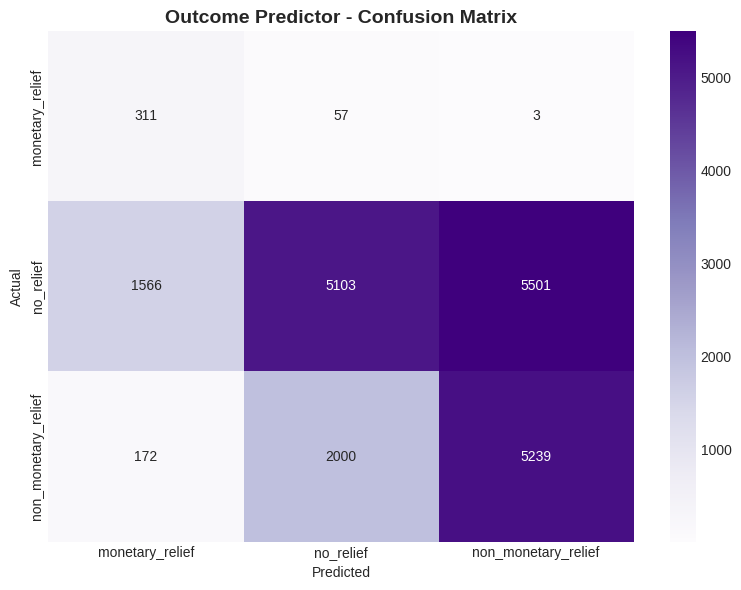

In [9]:
from scipy.sparse import hstack, csr_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score

# Encode outcome labels
outcome_encoder = LabelEncoder()
df['outcome_label'] = outcome_encoder.fit_transform(df['outcome'])
print(f'Outcome classes: {outcome_encoder.classes_}')

# Use a fresh TF-IDF for outcome prediction
outcome_vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=10)
X_text = outcome_vectorizer.fit_transform(df['cleaned_narrative'])

# Combine text features with engineered numerical features
extra_features = csr_matrix(df[['narrative_length', 'word_count', 'has_dollar_amount', 'has_legal_terms']].values)
X_combined = hstack([X_text, extra_features])
y_outcome = df['outcome_label']

X_train, X_test, y_train, y_test = train_test_split(X_combined, y_outcome, test_size=0.2, random_state=42, stratify=y_outcome)

print('\nTraining Outcome Predictor...')
outcome_model = LogisticRegression(max_iter=500, n_jobs=-1, C=0.5, class_weight='balanced')
outcome_model.fit(X_train, y_train)

y_pred = outcome_model.predict(X_test)
y_pred_proba = outcome_model.predict_proba(X_test)

print(f'\nOutcome Predictor Accuracy: {accuracy_score(y_test, y_pred):.3f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=outcome_encoder.classes_, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=outcome_encoder.classes_, yticklabels=outcome_encoder.classes_)
plt.title('Outcome Predictor - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 9: MODEL 3 - Successful Complaint Pattern Mining

Extract the words/phrases that appear most often in WINNING complaints (those that got monetary relief). These patterns inform the AI letter generation.

In [10]:
from sklearn.feature_extraction.text import CountVectorizer
import json

# Separate winning vs losing complaints
winners = df[df['outcome'] == 'monetary_relief']['cleaned_narrative']
losers = df[df['outcome'] == 'no_relief']['cleaned_narrative']

print(f'Winning complaints (got money): {len(winners):,}')
print(f'Losing complaints (no relief): {len(losers):,}')

# Find words/phrases distinctly common in winners vs losers
vec = CountVectorizer(max_features=2000, ngram_range=(1, 3), min_df=20, stop_words='english')
vec.fit(pd.concat([winners, losers]))

winner_counts = vec.transform(winners).sum(axis=0).A1
loser_counts = vec.transform(losers).sum(axis=0).A1
vocab = vec.get_feature_names_out()

# Calculate ratio (smoothed) - higher ratio = more characteristic of winners
winner_rate = winner_counts / max(len(winners), 1)
loser_rate = loser_counts / max(len(losers), 1)
lift = (winner_rate + 0.0001) / (loser_rate + 0.0001)

# Get top winning patterns (appearing at least 50 times)
top_indices = [(i, vocab[i], lift[i], winner_counts[i]) for i in range(len(vocab)) if winner_counts[i] >= 50]
top_indices.sort(key=lambda x: x[2], reverse=True)

winning_patterns = {phrase: round(float(score), 2) for _, phrase, score, _ in top_indices[:100]}

print('\nTop 20 phrases that appear in WINNING complaints:')
for phrase, score in list(winning_patterns.items())[:20]:
    print(f'  {phrase:<40} (lift: {score}x)')

# Save patterns for use by the Flask app
with open('/content/winning_patterns.json', 'w') as f:
    json.dump(winning_patterns, f, indent=2)
print('\nWinning patterns saved.')

Winning complaints (got money): 1,854
Losing complaints (no relief): 60,848

Top 20 phrases that appear in WINNING complaints:
  citi                                     (lift: 17.51x)
  boa                                      (lift: 16.3x)
  late fee                                 (lift: 15.35x)
  citibank                                 (lift: 14.83x)
  atm                                      (lift: 14.54x)
  bank america                             (lift: 13.9x)
  america                                  (lift: 12.79x)
  bonus                                    (lift: 12.77x)
  store                                    (lift: 11.79x)
  reversed                                 (lift: 11.73x)
  ticket                                   (lift: 10.49x)
  paypal                                   (lift: 10.46x)
  fee                                      (lift: 8.85x)
  refunded                                 (lift: 8.68x)
  merchant                                 (lift: 8.4x)
  debit c

## Cell 10: Build company-level resolution rate database

For each company, calculate: out of all complaints, what % got monetary relief? This shows users how 'fair' a company historically is.

In [11]:
company_stats = df.groupby('Company').agg(
    total_complaints=('outcome', 'count'),
    monetary_relief_rate=('outcome', lambda x: (x == 'monetary_relief').mean()),
    any_relief_rate=('outcome', lambda x: (x.isin(['monetary_relief', 'non_monetary_relief'])).mean())
).reset_index()

# Filter to companies with at least 50 complaints (for reliable rates)
company_stats = company_stats[company_stats['total_complaints'] >= 50].copy()
company_stats['monetary_relief_rate'] = (company_stats['monetary_relief_rate'] * 100).round(1)
company_stats['any_relief_rate'] = (company_stats['any_relief_rate'] * 100).round(1)
company_stats = company_stats.sort_values('total_complaints', ascending=False).reset_index(drop=True)

print(f'Companies with 50+ complaints: {len(company_stats):,}')
print('\nTop 15 companies by complaint volume:')
print(company_stats.head(15).to_string(index=False))

company_stats.to_csv('/content/company_stats.csv', index=False)
print('\nCompany stats saved.')

Companies with 50+ complaints: 101

Top 15 companies by complaint volume:
                               Company  total_complaints  monetary_relief_rate  any_relief_rate
                         EQUIFAX, INC.             24010                   0.0             51.3
TRANSUNION INTERMEDIATE HOLDINGS, INC.             23649                   0.0             79.4
   Experian Information Solutions Inc.             22205                   0.0             13.4
                           Block, Inc.              1553                   0.1              0.1
     CAPITAL ONE FINANCIAL CORPORATION              1481                   5.9             18.0
                  JPMORGAN CHASE & CO.              1284                   8.3             18.0
                 WELLS FARGO & COMPANY              1194                   8.1             17.4
 BANK OF AMERICA, NATIONAL ASSOCIATION              1096                  28.6             36.5
                        CITIBANK, N.A.               962      

## Cell 11: Save all models and artifacts

In [12]:
import joblib
import os

os.makedirs('/content/clawback_models', exist_ok=True)

# Save Model 1: Category Classifier
joblib.dump(category_model, '/content/clawback_models/category_model.pkl')
joblib.dump(category_vectorizer, '/content/clawback_models/category_vectorizer.pkl')
joblib.dump(category_encoder, '/content/clawback_models/category_encoder.pkl')

# Save Model 2: Outcome Predictor
joblib.dump(outcome_model, '/content/clawback_models/outcome_model.pkl')
joblib.dump(outcome_vectorizer, '/content/clawback_models/outcome_vectorizer.pkl')
joblib.dump(outcome_encoder, '/content/clawback_models/outcome_encoder.pkl')

# Copy patterns and stats
import shutil
shutil.copy('/content/winning_patterns.json', '/content/clawback_models/')
shutil.copy('/content/company_stats.csv', '/content/clawback_models/')

# Show file sizes
for f in os.listdir('/content/clawback_models'):
    size_mb = os.path.getsize(f'/content/clawback_models/{f}') / (1024 * 1024)
    print(f'{f:<35} {size_mb:.2f} MB')

# Zip everything for download
shutil.make_archive('/content/clawback_models', 'zip', '/content/clawback_models')

print('\nAll models saved.')
print('Download clawback_models.zip and extract into your Flask project /models folder')

outcome_vectorizer.pkl              0.12 MB
category_vectorizer.pkl             0.20 MB
outcome_encoder.pkl                 0.00 MB
category_encoder.pkl                0.00 MB
company_stats.csv                   0.00 MB
winning_patterns.json               0.00 MB
outcome_model.pkl                   0.07 MB
category_model.pkl                  0.54 MB

All models saved.
Download clawback_models.zip and extract into your Flask project /models folder


## Cell 12: Download everything

In [13]:
from google.colab import files

files.download('/content/clawback_models.zip')
files.download('/content/eda_overview.png')
files.download('/content/confusion_matrix.png')

print('Downloads triggered. Move clawback_models.zip contents to your Flask project /models folder.')
print('Use eda_overview.png and confusion_matrix.png in your project report.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads triggered. Move clawback_models.zip contents to your Flask project /models folder.
Use eda_overview.png and confusion_matrix.png in your project report.


## You're done.

**What was built:**
1. Complaint Category Classifier (TF-IDF + Logistic Regression)
2. Resolution Outcome Predictor (TF-IDF + engineered features + Logistic Regression with class balancing)
3. Winning pattern extraction (CountVectorizer + lift analysis)
4. Company resolution rate database

**Files generated:**
- `clawback_models.zip` - drop into Flask project /models
- `eda_overview.png` - for your report
- `confusion_matrix.png` - for your report